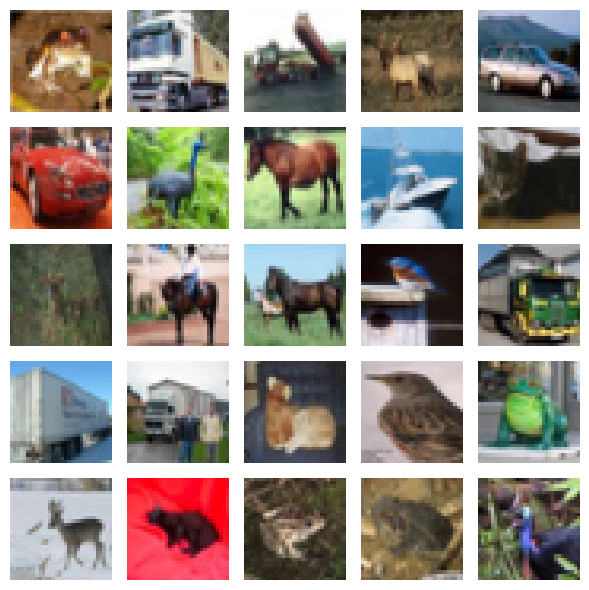

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.047135264..1.0700121].


Original shape:  (25, 3072)
PCA shape:  (25, 2)
PCA result:
 [[ -6.852994     1.8526506 ]
 [  1.6497792    5.9556007 ]
 [ 11.875815    -7.635948  ]
 [ -8.824608     0.39442155]
 [  0.68793464   0.46162415]
 [ -4.5157113   -6.2539716 ]
 [  0.8572222    1.8430123 ]
 [ -1.0399401    4.8968496 ]
 [  8.1508665   10.292145  ]
 [ -3.3964698   -8.208338  ]
 [ -7.7171      -0.8136495 ]
 [  9.368743    -3.6127894 ]
 [  9.695947    -3.0576837 ]
 [-12.221209     6.0283065 ]
 [ -2.2260253   -2.6425242 ]
 [  8.364714     2.682854  ]
 [ 11.307971    -4.3927627 ]
 [ -8.213013     3.0364084 ]
 [  6.3262095   -2.5244203 ]
 [ -0.8457305    5.8487577 ]
 [ 10.84029      7.895897  ]
 [ -6.1639795   -7.1815977 ]
 [ -9.48907     -1.7397436 ]
 [ -2.9843032   -1.5406541 ]
 [ -4.6353526   -1.5844475 ]]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11084518..0.7750042].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12931204..1.0049813].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.22760047..1.01813].


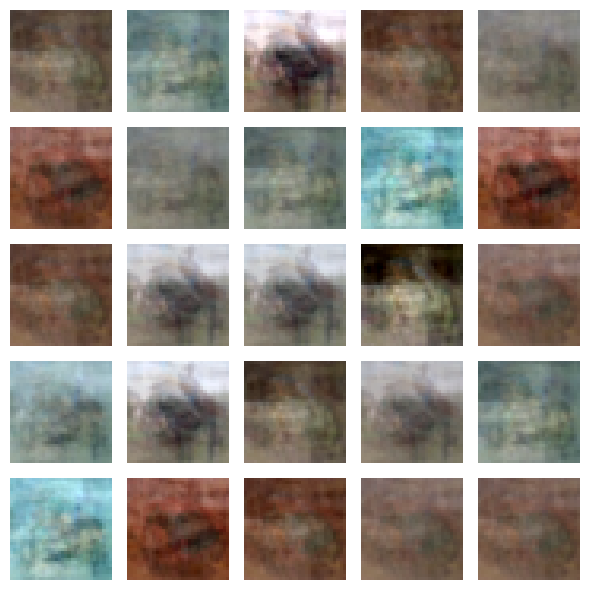

In [ ]:
#########################################################
#   JUST TESTING PCA AND LEARNING HOW TO USE MATPLOTLIB #
#########################################################

from torchvision import datasets, transforms
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

transform = transforms.ToTensor()

cifar10 = datasets.CIFAR10(
    root="../data/cifar10",
    train=True,
    download=True,
    transform=transform
)

images=[]

plt.figure(figsize=(6,6))

for i in range(25): #load 25 images
    image, label=cifar10[i]
    img_array=image.numpy()
    img_array=img_array.transpose(1,2,0)
    images.append(img_array)
    
    plt.subplot(5, 5, i+1)
    plt.imshow(img_array)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

images=np.array(images)  
N, H, W, C=images.shape
x=images.reshape(N, -1)

pca=PCA(n_components=2)
x_pca=pca.fit_transform(x)

print("Original shape: ", x.shape)
print("PCA shape: ", x_pca.shape)
print("PCA result:\n", x_pca)

reconstructed=pca.inverse_transform(x_pca)
r_images=reconstructed.reshape(N, 32, 32, 3)

plt.figure(figsize=(6,6))

for i in range (25):
    plt.subplot(5, 5, i+1)
    plt.imshow(r_images[i], interpolation='nearest')
    plt.axis('off')
    
plt.tight_layout()
plt.show()


